<a href="https://colab.research.google.com/github/Himanshu-86/ML_2026/blob/main/Practical_07_Geopolitical_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 07: Geopolitical Conflict Classification

## Objective
To develop a machine learning classification model that predicts the geopolitical relationship between countries using multi-dimensional features such as military strength, economy, ideology, and sentiment.


## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

## Load Dataset

In [ ]:
df = pd.read_csv("geopolitical_dataset.csv")
df.head()

,military_power_ratio,troop_movement,nuclear_capability,nuclear_warheads,gdp_ratio,sanctions_intensity,trade_dependency,ideology_distance,political_stability,historical_conflict,border_distance,news_sentiment,nationalism_index,leader_aggression,target
0,1.061810,46,0,20,1.514162,7,0.949273,0.844864,0.934033,5,793.537402,-0.740587,0.084002,0.274637,1
1,1.926071,11,0,157,1.915973,7,0.879601,0.359676,0.766351,6,85.599553,-0.092492,0.681526,0.273081,1
2,1.597991,61,0,268,0.903452,9,0.907042,0.687234,0.657950,0,183.457885,0.013860,0.680110,0.302622,1
3,1.397988,79,0,161,1.213110,6,0.991533,0.312834,0.823896,0,758.403673,0.374780,0.669080,0.612313,1
4,0.734028,87,1,259,1.451510,4,0.208315,0.060906,0.647520,4,21.986522,0.266567,0.942334,0.438333,1


## Data Preprocessing

In [ ]:
print(df.isnull().sum())

X = df.drop('target', axis=1)
y = df['target']

y = to_categorical(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

military_power_ratio    0
troop_movement          0
nuclear_capability      0
nuclear_warheads        0
gdp_ratio               0
sanctions_intensity     0
trade_dependency        0
ideology_distance       0
political_stability     0
historical_conflict     0
border_distance         0
news_sentiment          0
nationalism_index       0
leader_aggression       0
target                  0
dtype: int64


## Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Build Neural Network Model

In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(y.shape[1], activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Train Model

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1531 - loss: 1.7462 - val_accuracy: 0.3313 - val_loss: 1.4739
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3297 - loss: 1.4719 - val_accuracy: 0.4375 - val_loss: 1.2903
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4531 - loss: 1.3056 - val_accuracy: 0.5125 - val_loss: 1.1773
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4594 - loss: 1.2195 - val_accuracy: 0.5688 - val_loss: 1.1015
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4938 - loss: 1.1812 - val_accuracy: 0.6250 - val_loss: 1.0462
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5203 - loss: 1.1132 - val_accuracy: 0.6438 - val_loss: 0.9916
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5516 - loss: 1.0463 - val_accuracy: 0.7125 - val_loss: 0.9290
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5750 - loss: 1.0183 - val_accuracy: 0.7563 - val_loss

## Accuracy Visualization

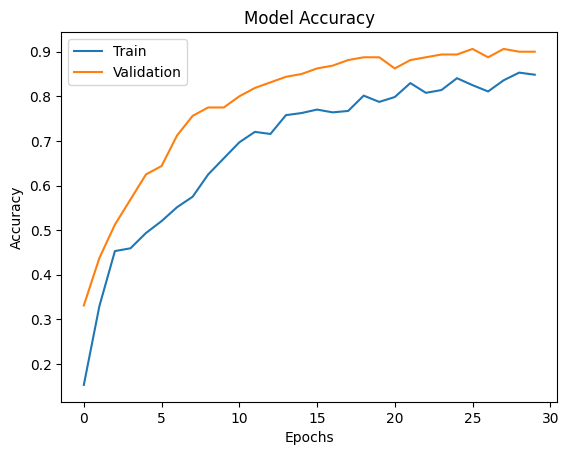

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])
plt.show()

## Model Evaluation

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9200 - loss: 0.2448  
Test Accuracy: 0.9200000166893005


## Classification Report

In [ ]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.95      0.99      0.97       100
           2       0.87      0.96      0.91        69
           3       0.94      0.64      0.76        25

    accuracy                           0.92       200
   macro avg       0.94      0.77      0.83       200
weighted avg       0.92      0.92      0.91       200



## Confusion Matrix

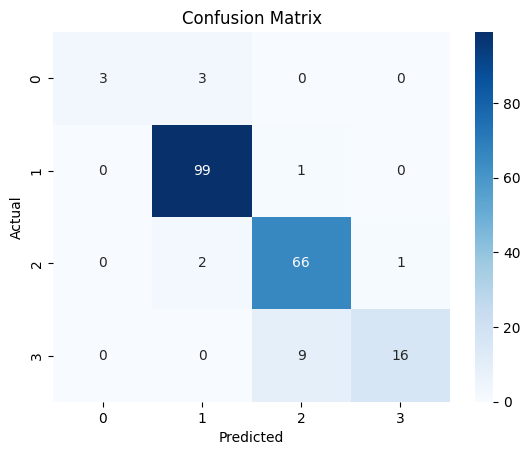

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Feature Correlation Analysis

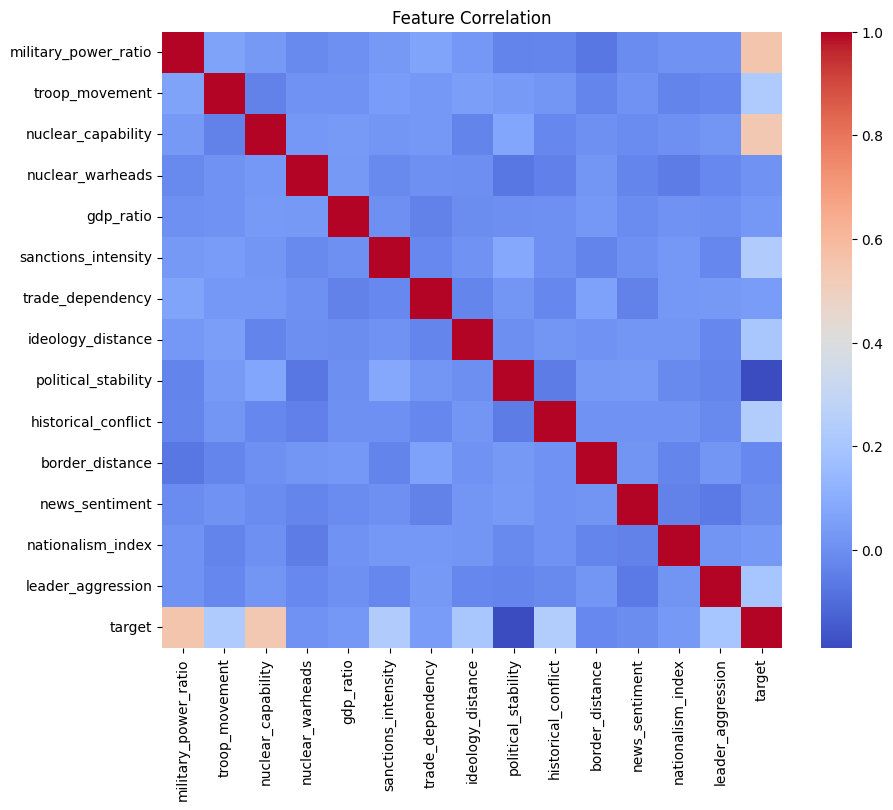

In [ ]:
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

## Conclusion

A Neural Network model was successfully developed to classify geopolitical relationships. The model achieved good accuracy and identified key feature relationships influencing global conflict prediction.